#### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Questions`
> Merge the two DataFrames on `Customer_ID` — what is the combined dataset shape?

> Which campaign generated the highest ROI? (ROI = (Revenue - Cost) / Cost × 100)

> What is the 3-month rolling average of monthly revenue across all customers?

> Which channel has the highest average spend per customer?

> Clean the `Customer_Name` column — remove extra spaces and convert to Title Case. How many unique customers are there per city?

In [2]:
# Dataset 1 — Campaign Performance Data
campaign_data = {
    'Campaign_ID': ['C001','C002','C003','C004'],
    'Campaign_Name': ['Summer Sale','Diwali Blast','New Year Push','Monsoon Deal'],
    'Channel': ['Social Media','Email','Search Ads','Social Media'],
    'Cost':    [50000, 30000, 45000, 35000],
    'Revenue': [180000, 95000, 160000, 105000]
}

In [3]:
# Dataset 2 — Customer Purchase Data
customer_data = {
    'Customer_ID': ['CU01','CU02','CU03','CU04','CU05',
                    'CU06','CU07','CU08','CU09','CU10',
                    'CU11','CU12','CU13','CU14','CU15',
                    'CU16','CU17','CU18','CU19','CU20'],

    'Customer_Name': ['  amit sharma','PRIYA SINGH','rahul verma  ','  SNEHA GUPTA',
                      'vikram joshi','  kavya patel  ','ARJUN MEHTA','meera kapoor',
                      '  rohit kumar','ANJALI SHARMA','dev malhotra','  POOJA NAIR  ',
                      'karan sinGH','NISHA REDDY','suresh iyer  ','  deepa menon',
                      'MANISH TIWARI','lata rao  ','  nitin jain','REKHA PILLAI'],

    'City': ['Mumbai','Delhi','Mumbai','Bangalore','Delhi',
             'Mumbai','Bangalore','Delhi','Mumbai','Bangalore',
             'Delhi','Mumbai','Bangalore','Delhi','Mumbai',
             'Bangalore','Delhi','Mumbai','Bangalore','Delhi'],

    'Campaign_ID': ['C001','C002','C001','C003','C002',
                    'C004','C003','C001','C004','C002',
                    'C001','C003','C004','C002','C001',
                    'C003','C004','C002','C001','C003'],

    'Purchase_Amount': [4500, 2200, 3800, 6200, 1900,
                        5100, 7300, 2800, 4200, 3500,
                        2100, 5800, 6700, 1800, 3200,
                        7100, 2500, 4800, 5900, 6400],

    'Purchase_Month': ['2024-01','2024-01','2024-02','2024-02','2024-03',
                       '2024-03','2024-04','2024-04','2024-05','2024-05',
                       '2024-06','2024-06','2024-01','2024-02','2024-03',
                       '2024-04','2024-05','2024-06','2024-01','2024-02']
}

#### `Step 1 :- Load and Explore Data`

In [4]:
# Convert to DataFrame
data_frame_campaign = pd.DataFrame(campaign_data)

data_frame_campaign

,Campaign_ID,Campaign_Name,Channel,Cost,Revenue
0,C001,Summer Sale,Social Media,50000,180000
1,C002,Diwali Blast,Email,30000,95000
2,C003,New Year Push,Search Ads,45000,160000
3,C004,Monsoon Deal,Social Media,35000,105000


In [5]:
# Convert to DataFrame
data_frame_customer = pd.DataFrame(customer_data)

data_frame_customer

,Customer_ID,Customer_Name,City,Campaign_ID,Purchase_Amount,Purchase_Month
0,CU01,amit sharma,Mumbai,C001,4500,2024-01
1,CU02,PRIYA SINGH,Delhi,C002,2200,2024-01
2,CU03,rahul verma,Mumbai,C001,3800,2024-02
3,CU04,SNEHA GUPTA,Bangalore,C003,6200,2024-02
4,CU05,vikram joshi,Delhi,C002,1900,2024-03
5,CU06,kavya patel,Mumbai,C004,5100,2024-03
6,CU07,ARJUN MEHTA,Bangalore,C003,7300,2024-04
7,CU08,meera kapoor,Delhi,C001,2800,2024-04
8,CU09,rohit kumar,Mumbai,C004,4200,2024-05
9,CU10,ANJALI SHARMA,Bangalore,C002,3500,2024-05


#### `Step 2 :- Data Validation`

In [6]:
# Check shapes and columns before merge
print('Campaign Shape:', data_frame_campaign.shape)

print('Customer Shape:', data_frame_customer.shape)

print('\nCampaign Columns:', data_frame_campaign.columns.tolist())

print('\nCustomer Columns:', data_frame_customer.columns.tolist())

Campaign Shape: (4, 5)
Customer Shape: (20, 6)

Campaign Columns: ['Campaign_ID', 'Campaign_Name', 'Channel', 'Cost', 'Revenue']

Customer Columns: ['Customer_ID', 'Customer_Name', 'City', 'Campaign_ID', 'Purchase_Amount', 'Purchase_Month']


#### `Step 3 :- Merge Validation`

In [7]:
# Merge customer data with campaign data on Campaign_ID
data_frame_merged = pd.merge(data_frame_customer, data_frame_campaign, on = 'Campaign_ID', how = 'left')

print(data_frame_merged.shape)

data_frame_merged

(20, 10)


,Customer_ID,Customer_Name,City,Campaign_ID,Purchase_Amount,Purchase_Month,Campaign_Name,Channel,Cost,Revenue
0,CU01,amit sharma,Mumbai,C001,4500,2024-01,Summer Sale,Social Media,50000,180000
1,CU02,PRIYA SINGH,Delhi,C002,2200,2024-01,Diwali Blast,Email,30000,95000
2,CU03,rahul verma,Mumbai,C001,3800,2024-02,Summer Sale,Social Media,50000,180000
3,CU04,SNEHA GUPTA,Bangalore,C003,6200,2024-02,New Year Push,Search Ads,45000,160000
4,CU05,vikram joshi,Delhi,C002,1900,2024-03,Diwali Blast,Email,30000,95000
5,CU06,kavya patel,Mumbai,C004,5100,2024-03,Monsoon Deal,Social Media,35000,105000
6,CU07,ARJUN MEHTA,Bangalore,C003,7300,2024-04,New Year Push,Search Ads,45000,160000
7,CU08,meera kapoor,Delhi,C001,2800,2024-04,Summer Sale,Social Media,50000,180000
8,CU09,rohit kumar,Mumbai,C004,4200,2024-05,Monsoon Deal,Social Media,35000,105000
9,CU10,ANJALI SHARMA,Bangalore,C002,3500,2024-05,Diwali Blast,Email,30000,95000


In [8]:
# check for nulls
print('\nNull Check:\n', data_frame_merged.isnull().sum())


Null Check:
 Customer_ID        0
Customer_Name      0
City               0
Campaign_ID        0
Purchase_Amount    0
Purchase_Month     0
Campaign_Name      0
Channel            0
Cost               0
Revenue            0
dtype: int64


#### `Step 4 :- ROI Analysis`

In [9]:
# # Calculate ROI for each campaign :- ROI = (Revenue - Cost) / Cost × 100
data_frame_campaign['ROI'] = ((data_frame_campaign['Revenue'] - data_frame_campaign['Cost']) / data_frame_campaign['Cost'] * 100).round(2)

data_frame_campaign[['Campaign_Name','ROI']]

,Campaign_Name,ROI
0,Summer Sale,260.00
1,Diwali Blast,216.67
2,New Year Push,255.56
3,Monsoon Deal,200.00


In [10]:
# Identify highest ROI campaign
highest_roi = data_frame_campaign.loc[data_frame_campaign['ROI'].idxmax()]

print('\nHighest ROI:\n', highest_roi)


Highest ROI:
 Campaign_ID              C001
Campaign_Name     Summer Sale
Channel          Social Media
Cost                    50000
Revenue                180000
ROI                     260.0
Name: 0, dtype: object


#### `Step 5 :- Monthly Revenue`

In [11]:
# Convert month column to datetime, group by month and calculate revenue
data_frame_merged['Purchase_Month'] = pd.to_datetime(data_frame_merged['Purchase_Month'])

monthly_revenue = data_frame_merged.groupby(data_frame_merged['Purchase_Month'].dt.to_period('M'))['Purchase_Amount'].sum()

print(monthly_revenue)

# Identify highest and lowest months
print('\nHighest Month:', monthly_revenue.idxmax(), monthly_revenue.max())

print('Lowest Month:', monthly_revenue.idxmin(), monthly_revenue.min())

Purchase_Month
2024-01    19300
2024-02    18200
2024-03    10200
2024-04    17200
2024-05    10200
2024-06    12700
Freq: M, Name: Purchase_Amount, dtype: int64

Highest Month: 2024-01 19300
Lowest Month: 2024-03 10200


#### `Step 6 :- Rolling Average`

In [12]:
# Calculate 3-month rolling average
rolling_average = monthly_revenue.rolling(window = 3, min_periods = 1).mean().round(2)

rolling_average

Purchase_Month
2024-01    19300.00
2024-02    18750.00
2024-03    15900.00
2024-04    15200.00
2024-05    12533.33
2024-06    13366.67
Freq: M, Name: Purchase_Amount, dtype: float64

#### `Step 7 :- Channel Spend`

In [13]:
# Average spend per customer by channel
channel_spend = data_frame_merged.groupby('Channel')['Purchase_Amount'].mean().round(2)

print(channel_spend)

print('\nHighest Channel:', channel_spend.idxmax(), channel_spend.max())

Channel
Email           2840.0
Search Ads      6560.0
Social Media    4080.0
Name: Purchase_Amount, dtype: float64

Highest Channel: Search Ads 6560.0


#### `Step 8 :- Clean Customer_Name and Count Unique Customers per City`

In [14]:
# Show before cleaning
print('Before Cleaning:\n', data_frame_customer['Customer_Name'].head().tolist())

# Remove spaces and convert to Title Case
data_frame_merged['Customer_Name'] = data_frame_merged['Customer_Name'].str.strip().str.title()

# Show after cleaning
print('After Cleaning:\n', data_frame_merged['Customer_Name'].head().tolist())

Before Cleaning:
 ['  amit sharma', 'PRIYA SINGH', 'rahul verma  ', '  SNEHA GUPTA', 'vikram joshi']
After Cleaning:
 ['Amit Sharma', 'Priya Singh', 'Rahul Verma', 'Sneha Gupta', 'Vikram Joshi']


In [15]:
# Count unique customers per city
city_customers = data_frame_merged.groupby('City')['Customer_ID'].nunique()

city_customers

City
Bangalore    6
Delhi        7
Mumbai       7
Name: Customer_ID, dtype: int64

#### `Step 9 :- Chart 1 — ROI by Campaign`

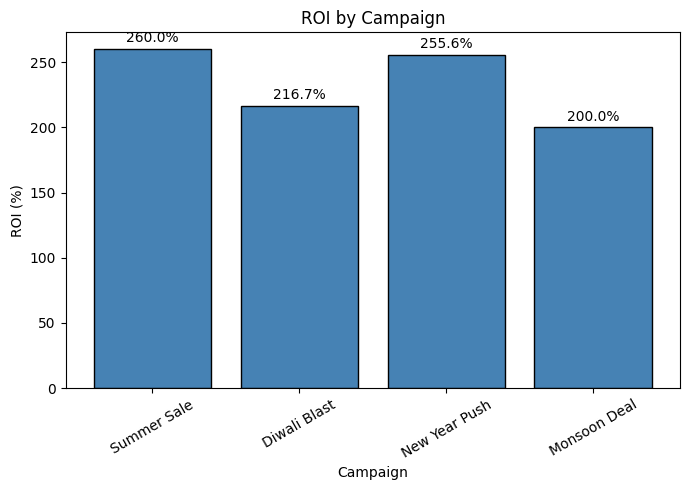

In [16]:
# Bar chart with annotations for ROI
figure, roi_axis = plt.subplots(figsize =(7, 5))

campaigns = data_frame_campaign['Campaign_Name']

roi_values = data_frame_campaign['ROI']

bars = roi_axis.bar(campaigns, roi_values, color = 'steelblue', edgecolor = 'black')

# Annotate ROI values on bars
for bar in bars:
    height = bar.get_height()
    roi_axis.annotate(f'{height:.1f}%', xy = (bar.get_x() + bar.get_width() / 2, height), xytext = (0, 5), textcoords = 'offset points', ha = 'center', fontsize = 10)

roi_axis.set_title('ROI by Campaign')

roi_axis.set_xlabel('Campaign')

roi_axis.set_ylabel('ROI (%)')

plt.xticks(rotation = 30)

plt.tight_layout()

plt.savefig('8_Insights_Campaign_ROI.png')

plt.show()

#### `Step 10 :- Chart 2 — Monthly Revenue vs Rolling Average`

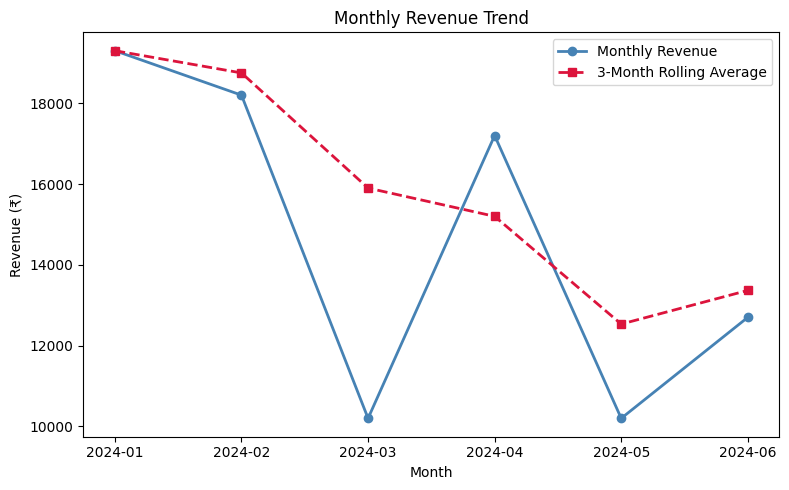

In [17]:
# Line chart comparing monthly revenue and rolling average
months = monthly_revenue.index.astype(str)

plt.figure(figsize = (8, 5))

plt.plot(months, monthly_revenue, marker ='o', color = 'steelblue', label = 'Monthly Revenue', linewidth = 2)

plt.plot(months, rolling_average, marker = 's', color = 'crimson', linestyle = '--', label = '3-Month Rolling Average', linewidth = 2)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue (₹)")

plt.legend()

plt.tight_layout()

plt.savefig("8_Insights_Revenue_Trend.png")

plt.show()

#### `Step 11 :- Print Outputs`

In [18]:
# Display all computed results clearly
print('\n--- FINAL OUTPUTS ---')

print(f'\nMerged Shape: {data_frame_merged.shape}')

print(f'\nROI per Campaign:\n{data_frame_campaign[["Campaign_Name","ROI"]]}')

print(f'\nMonthly Revenue:\n{monthly_revenue}')

print(f'\n3-Month Rolling Average:\n{rolling_average}')

print(f'\nAverage Spend per Customer by Channel:\n{channel_spend}')

print(f'\nUnique Customers per City:\n{city_customers}')


--- FINAL OUTPUTS ---

Merged Shape: (20, 10)

ROI per Campaign:
   Campaign_Name     ROI
0    Summer Sale  260.00
1   Diwali Blast  216.67
2  New Year Push  255.56
3   Monsoon Deal  200.00

Monthly Revenue:
Purchase_Month
2024-01    19300
2024-02    18200
2024-03    10200
2024-04    17200
2024-05    10200
2024-06    12700
Freq: M, Name: Purchase_Amount, dtype: int64

3-Month Rolling Average:
Purchase_Month
2024-01    19300.00
2024-02    18750.00
2024-03    15900.00
2024-04    15200.00
2024-05    12533.33
2024-06    13366.67
Freq: M, Name: Purchase_Amount, dtype: float64

Average Spend per Customer by Channel:
Channel
Email           2840.0
Search Ads      6560.0
Social Media    4080.0
Name: Purchase_Amount, dtype: float64

Unique Customers per City:
City
Bangalore    6
Delhi        7
Mumbai       7
Name: Customer_ID, dtype: int64


#### `Information`
> Rows: 20

> Columns: 10

> Merge key: Campaign_ID

> ROI calculated for 4 campaigns

> Rolling average window = 3 months

#### `Data Insights`
> Merged dataset contains 20 rows and 10 columns.

> Highest ROI campaign: Summer Sale (260%).

> Highest monthly revenue: Jan (₹19,300).

> Lowest monthly revenue: Mar & May (₹10,200).

> Rolling average declined from ₹19,300 (Jan) to ₹12,533 (May), slight recovery in Jun (₹13,367).

> Highest average spend channel: Search Ads (₹6,560).

> Unique customers: Mumbai = 7, Delhi = 7, Bangalore = 6.

#### `Business Insights`
> Summer Sale delivered strongest ROI → repeat strategy.

> Search Ads customers spend the most → premium targeting opportunity.

> Revenue declined 35% from Jan to May → serious early warning signal.

> Customer base balanced in Mumbai & Delhi, Bangalore slightly behind.

#### `Risks`
> Declining revenue trend may indicate campaign fatigue.

> Heavy reliance on Search Ads → dependency risk.

> Email campaign ROI lower (216%) → underperformance.

#### `Opportunities`
> Increase budget for Summer Sale and Search Ads.

> Expand in Bangalore to balance customer distribution.

> Optimize Email campaigns for better ROI.

> Use rolling average monitoring for early detection.

#### `Recommendations`
> Increase budget for Summer Sale  
> - Evidence: ROI = 260%.

> Allocate more to Search Ads  
> - Evidence: Highest avg spend = ₹6,560.

> Investigate decline in rolling average immediately  
> - Evidence: Revenue dropped 35% from Jan to May.

> Expand in Bangalore  
> - Evidence: Only 6 customers vs 7 in Mumbai & Delhi.

#### `Expected Business Impact`
> Correct budget allocation → maximize ROI.

> Early detection of decline → prevent further revenue drop.

> Balanced customer acquisition → stronger market presence.

#### `Future Prediction`
> If decline is addressed, rolling average will stabilize above ₹15k.

> Summer Sale repeat campaign likely to deliver >250% ROI again.

> Bangalore expansion expected to bring parity with Mumbai & Delhi.